In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 상관관계와 산점도 분석
diamonds = sns.load_dataset('diamonds')
diamonds.head()


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [5]:
diamonds_sample = diamonds.sample(1000,random_state=42)

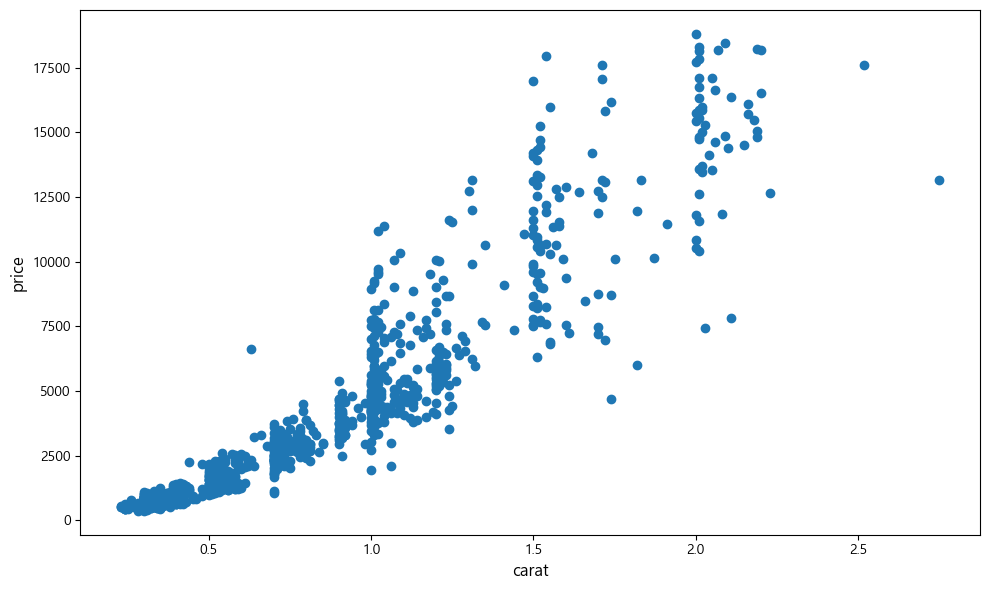

 상관계수 : 0.922


In [11]:
# 산점도 sctter : 캐럿이 가격에 미치는 영향
fig, ax = plt.subplots(figsize=(10, 6))

# sns.scatterplot(data=diamonds_sample, x='carat', y='price', ax=ax)
ax.scatter(x=diamonds_sample['carat'], y = diamonds_sample['price'])
ax.set_xlabel('carat', fontsize=12)
ax.set_ylabel('price', fontsize=12)

plt.tight_layout()
plt.show()

# 상관계수 계산
corr = diamonds['carat'].corr(diamonds['price'])
print(f" 상관계수 : {corr:.3f}")

np.float64(-1.0)

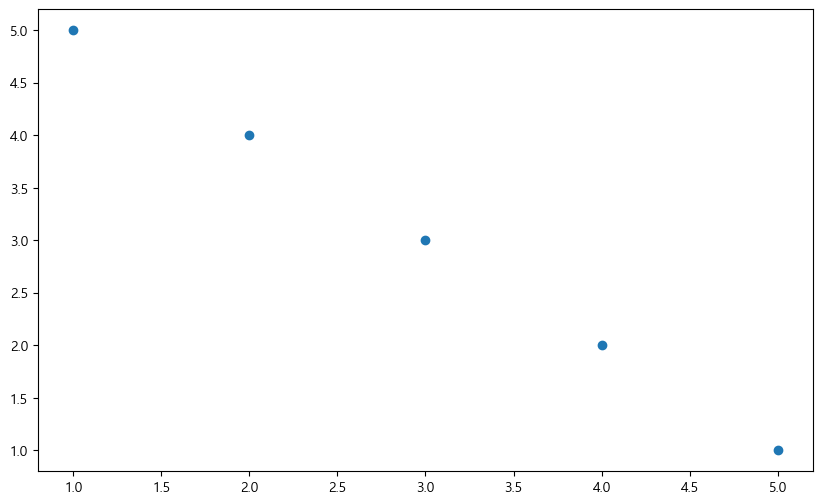

In [14]:
data = {
    'x' : [1, 2, 3, 4, 5],
    'y' : [5, 4, 3, 2, 1]
}
sample = pd.DataFrame(data)
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(sample['x'], sample['y'])
round(sample['x'].corr(sample['y']), 3)

<Axes: xlabel='carat', ylabel='price'>

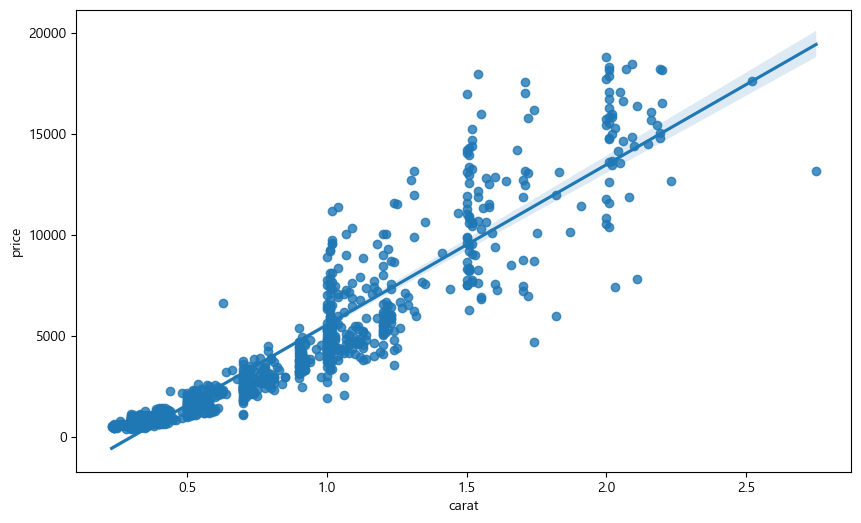

In [16]:

# Regplot : 회귀선
# 캐럿을 기준으로 적정 가격을 예측할 수 있나?
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(data=diamonds_sample, x='carat', y='price', ax=ax)

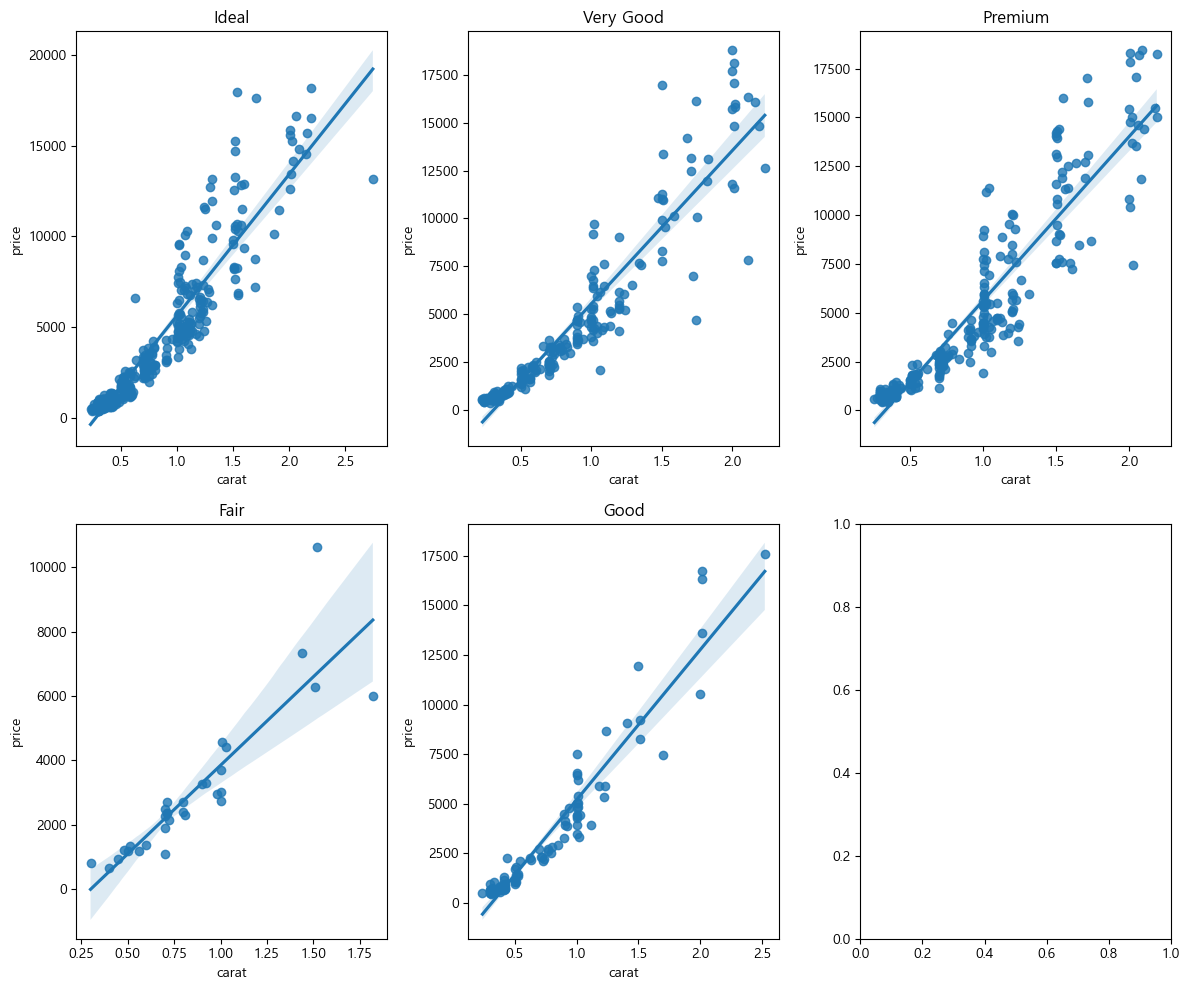

In [30]:
# 다이아몬드 등급(cut)에 따라서 가격패턴이 다른가?
fig, ax = plt.subplots(2,3,figsize=(12,10))

for index, cut in enumerate(diamonds_sample['cut'].unique()):
    sns.regplot(data=diamonds_sample[diamonds_sample['cut'] == cut],
                    x='carat', y='price', ax = ax[index//3, index % 3])
    ax[index//3, index % 3].set_title(cut)
plt.tight_layout()
plt.show()


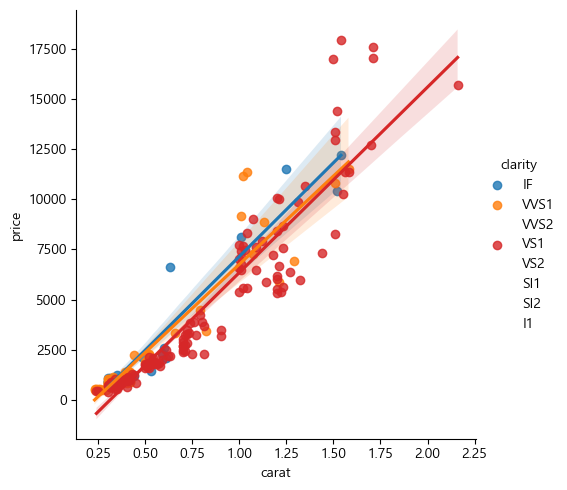

In [44]:
# 투명도(clarity) 별로 가격결정 패턴이 다른가
# IF , VVS1, VS1

diamonds_sample['clarity'].unique()

clarity_subset = diamonds_sample[ diamonds_sample['clarity'].isin(['IF', 'VVS1', 'VS1']) ]


sns.lmplot(data = clarity_subset, x = 'carat', y='price', hue='clarity')

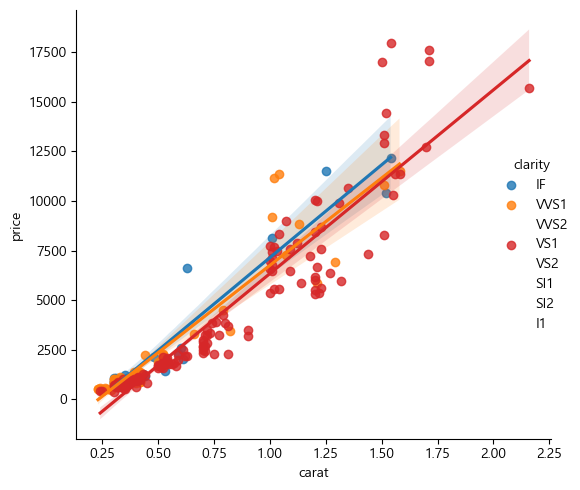

In [47]:
clarity_subset = diamonds_sample[ diamonds_sample['clarity'].isin(['IF', 'VVS1', 'VS1']) ]
g = sns.lmplot(data = clarity_subset, x='carat', y='price', hue='clarity')
plt.tight_layout()
plt.show()

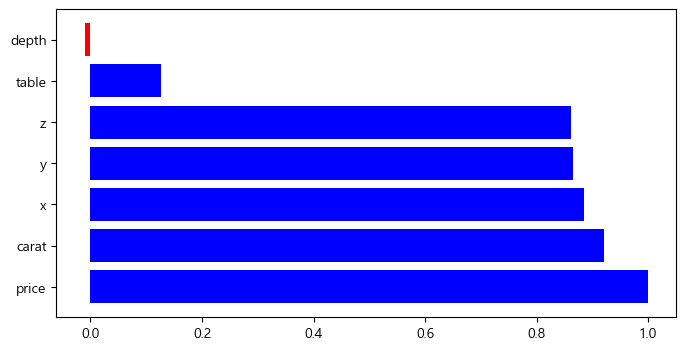

In [ ]:
# 어떤 속성이 가격에 가장 큰 영향을 미칠까?
# 수치형 변수들의 상관계수를 계산

numeric_cols = list(diamonds.describe().columns)
numeric_cols.remove('price')
collelation = diamonds[ numeric_cols + ['price'] ] .corr()['price'].sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8,4))
colors = ['blue' if x > 0 else 'red' for x in collelation.values]
bars = ax.barh(collelation.index, collelation.values, color = colors)




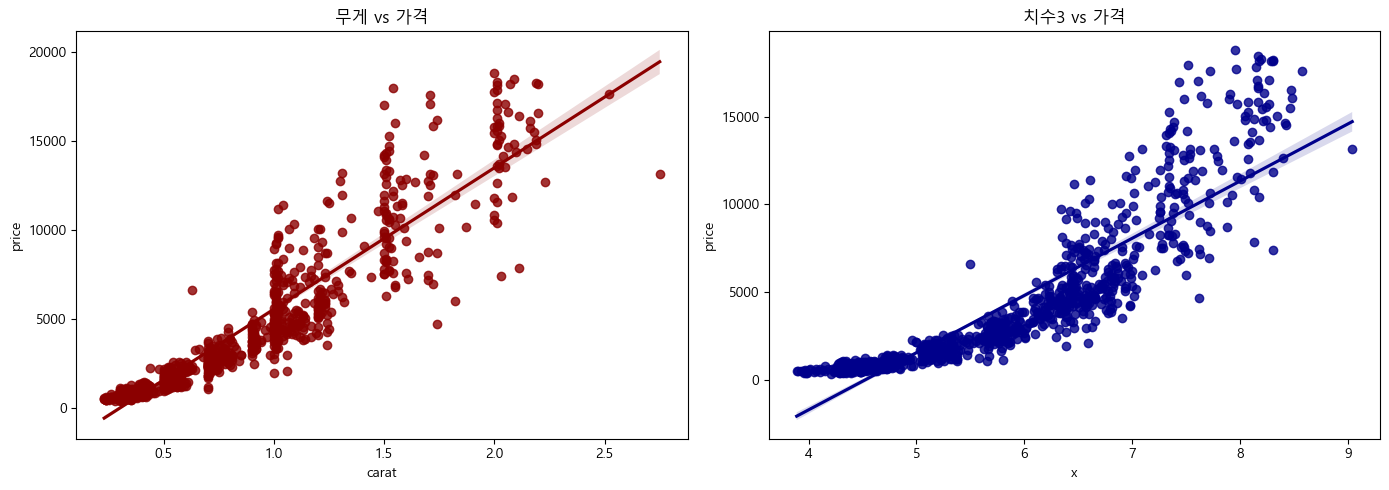

In [ ]:
# 상관관계 vs 인과관계
# 상관관계는 반드시 인과관계를 의미하지 않음
# 무게와 x 치수의 관계
fig, axes = plt.subplots(1,2,figsize = (14, 5))
# 좌측 Carat vs Price
sns.regplot(data = diamonds_sample, x='carat', y='price', ax=axes[0], color='darkred')
axes[0].set_title('무게 vs 가격')

# 우측 X vs Price
sns.regplot(data = diamonds_sample, x='x', y='price', ax=axes[1], color='darkblue')
axes[1].set_title('치수3 vs 가격')

plt.tight_layout()
plt.show()

# 무게가 증가하면 치수도 증가하는 관계 (치수 vs 가격 허위 상관관계)
# 추론할 때 불필요한 계수 즉 변수임... 따라서 머신러닝 할 때는 학습에서 제외


In [81]:
diamonds_sample[numeric_cols].corr()

,carat,depth,table,x,y,z
carat,1.000000,-0.078646,0.200590,0.980120,0.979933,0.978572
depth,-0.078646,1.000000,-0.344625,-0.127685,-0.127643,-0.009381
table,0.200590,-0.344625,1.000000,0.218992,0.212593,0.177378
x,0.980120,-0.127685,0.218992,1.000000,0.998434,0.992165
y,0.979933,-0.127643,0.212593,0.998434,1.000000,0.992446
z,0.978572,-0.009381,0.177378,0.992165,0.992446,1.000000
